### Set up

In [1]:
import torchvision
import torchvision.transforms.v2 as T
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import torchmetrics
import torch.nn.functional as F

In [2]:
if torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

### Load dataset

In [3]:
toTensor = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

In [4]:
train_and_valid_data = torchvision.datasets.FashionMNIST(root="datasets", train=True, download=True, transform=toTensor)
test_data = torchvision.datasets.FashionMNIST(root="datasets", train=False, download=True, transform=toTensor)

In [5]:
torch.manual_seed(42)
train_data, valid_data = torch.utils.data.random_split(train_and_valid_data, [55_000, 5_000])

In [6]:
train_and_valid_data.classes

['T-shirt/top',
 'Trouser',
 'Pullover',
 'Dress',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneaker',
 'Bag',
 'Ankle boot']

In [7]:
X_sample, y_sample = train_data[0]
y_sample, train_and_valid_data.classes[y_sample]

(9, 'Ankle boot')

In [8]:
X_sample.shape

torch.Size([1, 28, 28])

C:\Users\PRASHANTH N\AppData\Local\Temp\ipykernel_10064\487032299.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  plt.imshow(np.array(X_sample)[0].reshape(28, 28, 1))


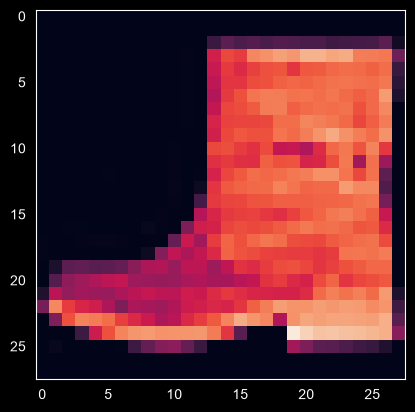

In [9]:
plt.imshow(np.array(X_sample)[0].reshape(28, 28, 1))
plt.grid()
plt.show()

In [10]:
batch_size = 256
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
valid_loader = DataLoader(valid_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, num_workers=4, prefetch_factor=10, persistent_workers=True, pin_memory=True)

### Model - Image Classifier

In [11]:
class ImageClassifier(nn.Module):
    def __init__(self, n_inputs, n_hidden1, n_hidden2, n_classes):
        super().__init__()
        self.mlp = nn.Sequential(nn.Flatten(), nn.Linear(n_inputs, n_hidden1), nn.ReLU(),
                                 nn.Linear(n_hidden1, n_hidden2), nn.ReLU(), nn.Linear(n_hidden2, n_classes))

    def forward(self, X):
        return self.mlp(X)

In [12]:
torch.manual_seed(42)
model = ImageClassifier(n_inputs=28 * 28, n_hidden1=300, n_hidden2=100, n_classes=10).to(device)
model

ImageClassifier(
  (mlp): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=300, bias=True)
    (2): ReLU()
    (3): Linear(in_features=300, out_features=100, bias=True)
    (4): ReLU()
    (5): Linear(in_features=100, out_features=10, bias=True)
  )
)

In [13]:
xentropy = nn.CrossEntropyLoss()
xentropy

CrossEntropyLoss()

In [14]:
accuracy = torchmetrics.Accuracy(task="multiclass", num_classes=10).to(device)
accuracy

MulticlassAccuracy()

In [15]:
learning_rate = 0.1
n_epochs = 10
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)

In [16]:
def train(model, optimizer, criterion, train_loader, valid_loader, n_epochs):
    model.train()
    losses = []
    val_losses = []
    accuracies = []
    val_accuracies = []
    for epoch in range(n_epochs):
        total_loss = 0.
        total_acc = 0.
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            total_loss += loss.item()
            total_acc += accuracy(y_pred, y_batch).item()
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
        mean_loss = total_loss / len(train_loader)
        train_accuracy = total_acc / len(train_loader)
        x_val, y_val = next(iter(valid_loader))
        y_val_pred = model(x_val.to(device))
        val_loss = criterion(y_val_pred, y_val.to(device))
        val_acc = accuracy(y_val_pred, y_val.to(device)).item()
        losses.append(mean_loss)
        val_losses.append(val_loss.item())
        accuracies.append(train_accuracy)
        val_accuracies.append(val_acc)
        print(f"Epoch {epoch + 1}/{n_epochs}, Loss: {mean_loss:.4f}, Validation Loss: {val_loss.item()}, Train Accuracy: {train_accuracy}, Validation Accuracy: {val_acc}")
    return losses, val_losses, accuracies, val_accuracies

In [17]:
train_loss, val_loss, train_acc, val_acc = train(model, optimizer, xentropy, train_loader, valid_loader, n_epochs)

Epoch 1/10, Loss: 1.0948, Validation Loss: 0.7892679572105408, Train Accuracy: 0.636206664595493, Validation Accuracy: 0.67578125
Epoch 2/10, Loss: 0.6035, Validation Loss: 0.6066993474960327, Train Accuracy: 0.7834033162094826, Validation Accuracy: 0.8046875
Epoch 3/10, Loss: 0.5156, Validation Loss: 0.6781506538391113, Train Accuracy: 0.8169142980908238, Validation Accuracy: 0.79296875
Epoch 4/10, Loss: 0.4707, Validation Loss: 0.6566370129585266, Train Accuracy: 0.8321496824885524, Validation Accuracy: 0.8046875
Epoch 5/10, Loss: 0.4401, Validation Loss: 0.5313574075698853, Train Accuracy: 0.8430885281673698, Validation Accuracy: 0.82421875
Epoch 6/10, Loss: 0.4171, Validation Loss: 0.5392155647277832, Train Accuracy: 0.8514299364977105, Validation Accuracy: 0.83984375
Epoch 7/10, Loss: 0.4019, Validation Loss: 0.4930056035518646, Train Accuracy: 0.8567735250606093, Validation Accuracy: 0.83203125
Epoch 8/10, Loss: 0.3859, Validation Loss: 0.47088176012039185, Train Accuracy: 0.8609

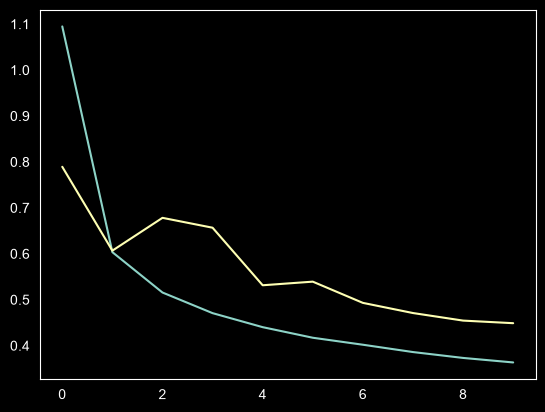

In [18]:
plt.plot(list(range(n_epochs)), train_loss)
plt.plot(list(range(n_epochs)), val_loss)
plt.grid()
plt.show()

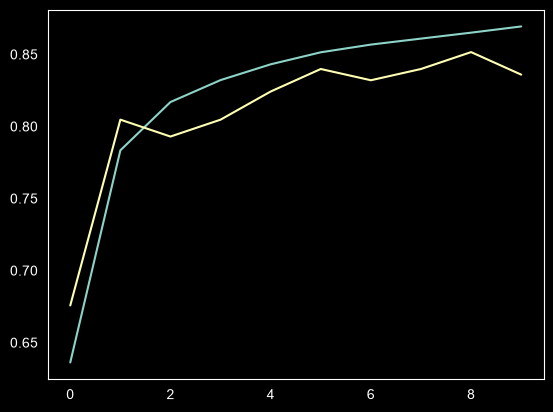

In [19]:
plt.plot(list(range(n_epochs)), train_acc)
plt.plot(list(range(n_epochs)), val_acc)
plt.grid()
plt.show()

### Evaluate

In [20]:
with torch.no_grad():
    x_test, y_test = next(iter(test_loader))
    y_test_pred = model(x_test.to(device))
    loss_test = xentropy(y_test_pred, y_test.to(device))
loss_test

tensor(0.3703, device='cuda:0')

In [21]:
accuracy(y_test_pred, y_test.to(device)).item()

0.87109375

In [22]:
model.eval()
X_new, y_new = next(iter(valid_loader))
X_new = X_new[:3].to(device)
with torch.no_grad():
    y_pred_logits = model(X_new)
    y_pred = y_pred_logits.argmax(dim=1) # index of the largest logit
    print(y_pred)
    print([train_and_valid_data.classes[index] for index in y_pred])

tensor([7, 4, 2], device='cuda:0')
['Sneaker', 'Coat', 'Pullover']


In [23]:
y_pred_logits

tensor([[ -2.3122,  -2.0120,  -2.8335,  -1.2814,  -3.0162,   3.7888,  -3.0836,
           7.4046,   1.5892,   3.4224],
        [ -0.4035,  -0.1391,   6.6429,   0.9992,  10.5448,  -5.8006,   4.9634,
          -7.9855,   1.4417, -10.4091],
        [  1.3193,  -2.5898,   6.5685,   2.3316,   5.0008,  -4.4960,   5.2664,
          -7.1320,   2.2621,  -7.2964]], device='cuda:0')

In [24]:
y_proba = F.softmax(y_pred_logits, dim=1)
y_proba.round(decimals=3)

tensor([[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0260, 0.0000, 0.9530, 0.0030,
         0.0180],
        [0.0000, 0.0000, 0.0200, 0.0000, 0.9760, 0.0000, 0.0040, 0.0000, 0.0000,
         0.0000],
        [0.0030, 0.0000, 0.6610, 0.0100, 0.1380, 0.0000, 0.1800, 0.0000, 0.0090,
         0.0000]], device='cuda:0')

In [25]:
X = X_new.to("cpu")
y = list(y_pred.to("cpu"))

C:\Users\PRASHANTH N\AppData\Local\Temp\ipykernel_10064\3059679686.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  i = np.array(img).reshape(28, 28)


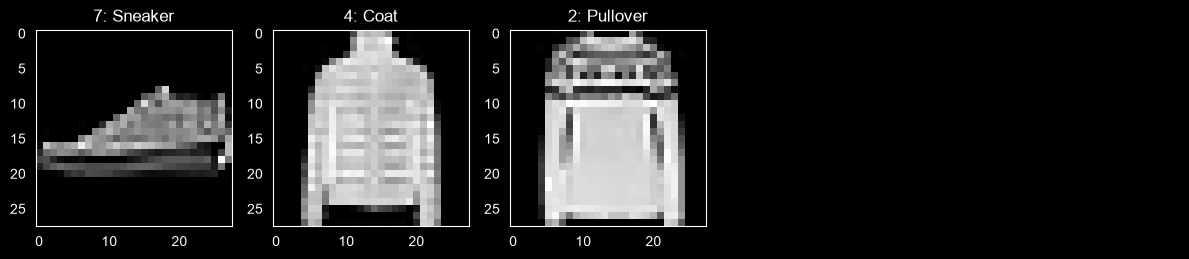

In [26]:
n = len(X)
cols = 5
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(12, 2.5 * rows))
axes = np.array(axes).reshape(-1)
for index, img in enumerate(X):
    i = np.array(img).reshape(28, 28)
    axes[index].imshow(i, cmap="gray")
    axes[index].set_title(f"{int(y[index])}: {train_and_valid_data.classes[int(y[index])]}")
    axes[index].grid()

for ax in axes[len(X):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
y_top3_logits, y_top3_indices = torch.topk(y_pred_logits, k=3, dim=1)
y_top3_probas = F.softmax(y_top3_logits, dim=1)
y_top3_probas.round(decimals=3)

tensor([[0.9560, 0.0260, 0.0180],
        [0.9770, 0.0200, 0.0040],
        [0.6750, 0.1840, 0.1410]], device='cuda:0')

In [28]:
y_top3_indices

tensor([[7, 5, 9],
        [4, 2, 6],
        [2, 6, 4]], device='cuda:0')